<a href="https://colab.research.google.com/github/augustojrr/redes-neurais-UFPI/blob/main/Perceptron_Porta_AND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ATIVIDADE REDES NEURAIS

---

##Assunto: Perceptron
##Aluno: Augusto César de Sousa Passos Júnior

---

###Introdução: O Perceptron é a unidade fundamental das Redes Neurais Artificiais, funcionando como um classificador linear inspirado no comportamento de um neurônio biológico. Ele processa sinais de entrada multiplicados por pesos, soma-os a um termo de ajuste (bias) e utiliza uma função de ativação para decidir a saída.

###Nesta atividade, o Perceptron é treinado para aprender a lógica de uma porta AND, onde deve encontrar uma fronteira de decisão (reta) capaz de separar corretamente os resultados binários no plano cartesiano através de ajustes sucessivos em seus parâmetros.










#Código do PERCEPTRON (simplificado)

```python
  def perceptron(input,target,weight,bias):

    a = (input*weight) + bias
    valor_calculado = degrau(a)

    erro = target - valor_calculado

    weight_new = weight + (erro*input)

    bias_new = bias + erro

    return weight_new, bias_new


##Código do Perceptron, da função Degrau, e do treinamento, onde ele se comporta como uma porta lógica AND.

In [ ]:
def degrau(x): # Implementação da função DEGRAU
  if x >= 0:
    return 1
  else:
    return 0

def perceptron(input,target,weight,bias): # Criando a função perceptron com os parâmetros (entradas, alvos, pesos,
                                          # bias).
  fator_aprendizado = 0.02 # passo que o algoritmo dá ao ajustar os pesos e o bias para reduzir o erro.
  somatorio = bias # inicializando a variavel somatorio com o valor de bias, pois posteriormente vamos somar as
                   # entradas com os seus respectivos pesos e no final precisaremos somar com o bias.

  for i in range(len(input)): # um for que percorre cada entrada individual
                              # (neste caso, as 2 entradas x1 e x2 de cada exemplo).
    a = (input[i]*weight[i]) # variavel que armazena o valor de cada entrada vezes o seu peso correspondente.
    somatorio += a # somando os valores (entrada x peso) na variavel somatorio, que no final já estará somado com
                   # o valor da bias.

  valor_calculado = degrau(somatorio) # valor calculado com base na função de ativação, que é a função degrau.
  erro = target - valor_calculado # calculo do erro, que é o meu alvo menos o valor calculado a partir da saída
                                  # gerada pela função de ativação.

  new_weight = [] # lista vazia para armazenar os novos pesos.

  for i in range(len(weight)): # um for com range correspondente a quantidade de pesos.
    weight_new = weight[i] + (fator_aprendizado*erro*input[i]) # calculando o novo_peso, que será o peso_antigo +
                                             # + (erro x entrada_correspondente x fator_aprendizado).
    new_weight.append(weight_new) # função append para salvar o valor do novo_peso na lista de novos_pesos.

  bias_new = bias + (erro*fator_aprendizado) # calculo da nova_bias, que é a antiga_bias + (erro*fator_aprendizado)

  return new_weight, bias_new, erro # a nossa função perceptron nós retorna: novos_pesos, nova_bias e o erro.


inputs = [[0,0],[0,1],[1,0],[1,1]] # lista dos meus pares de entradas.
targets = [0,0,0,1] # lista dos meu alvos, correspondentes aos pares de entradas
w = [0,0] # inicializo meus pesos em 0, como só são duas entradas, apenas dois pesos
b = 0 # inicializo a minha bias em 0

for epoca in range(20): # um for com 20 epocas, que seriam 20 ciclos de treinamento.

  for i in range(len(inputs)):
    w, b, e = perceptron(inputs[i],targets[i],w,b) # aqui, eu coloco 3 variaveis para salvarem os valores retornados
                                                   # na função perceptron, e a cada nova iteração, os novos valores
                                                   # de peso, e de bias, já são automaticamente utilizados.

print("--- Treino Finalizado! O neurônio convergiu. ---")
print(f"Pesos Finais: {w}")
print(f"Bias Final: {b}")


--- Treino Finalizado! O neurônio convergiu. ---

Pesos Finais: [0.04, 0.02]
Bias Final: -0.06


##Como já foi apresentado a parte matemática do Perceptron, agora vamos para a parte gráfica.

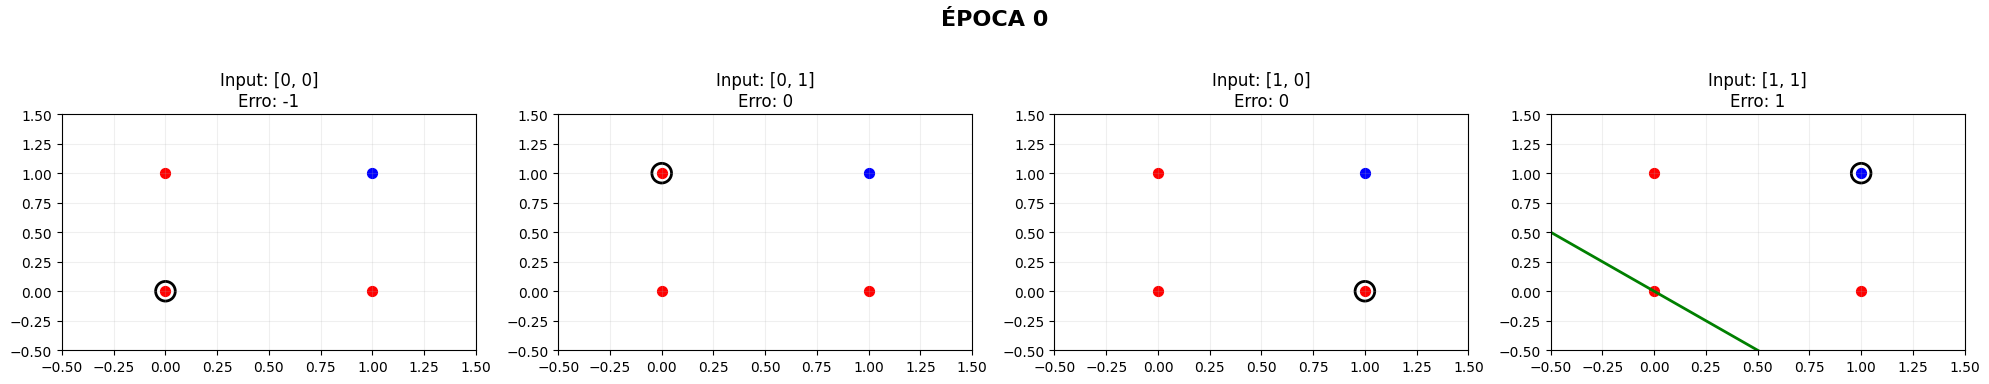

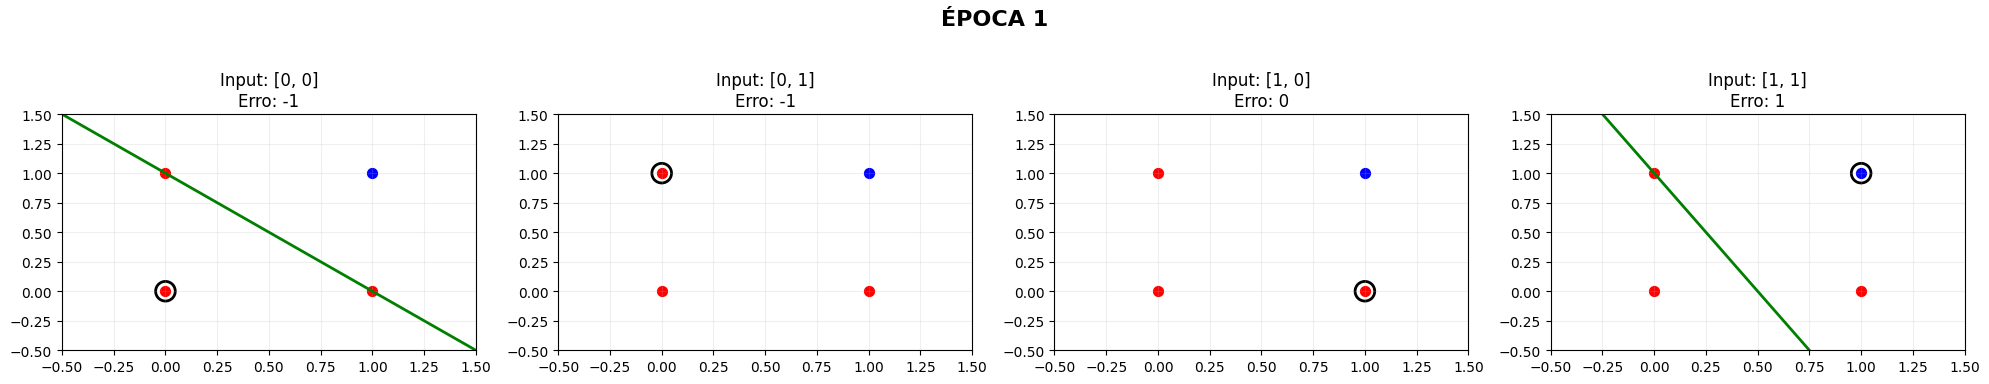

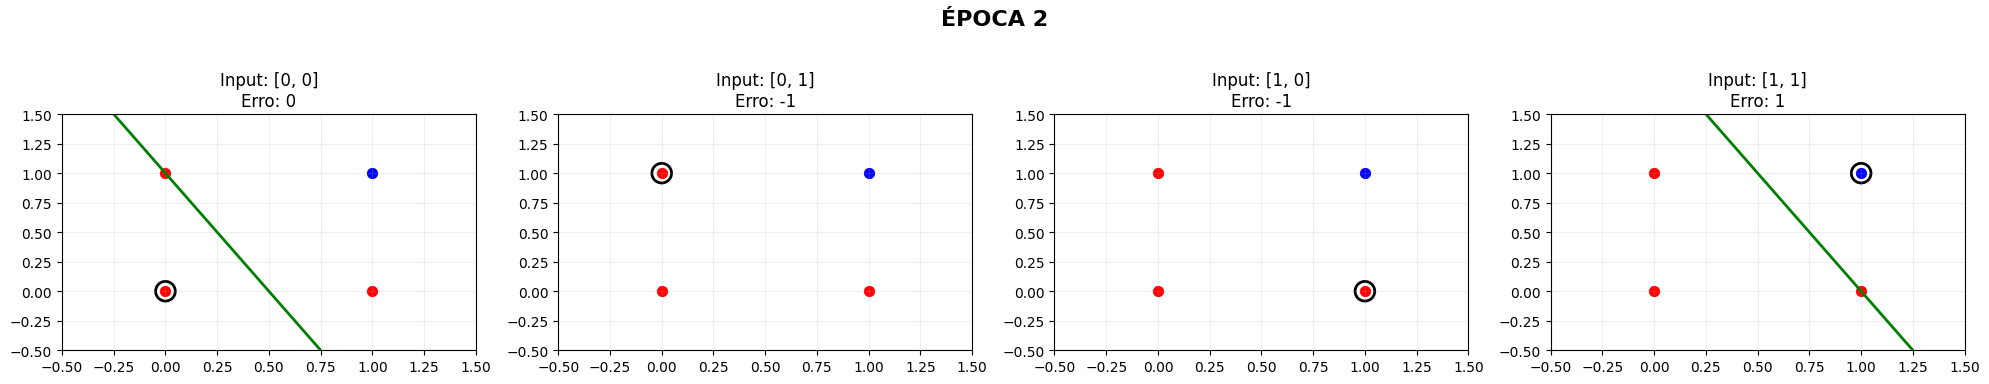

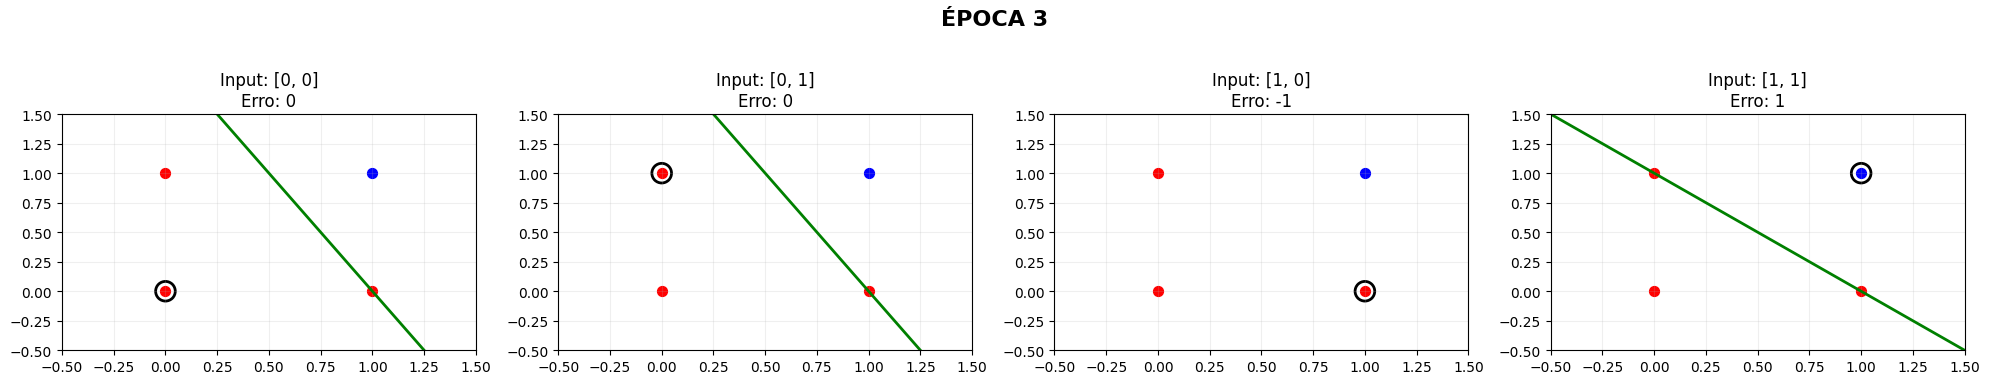

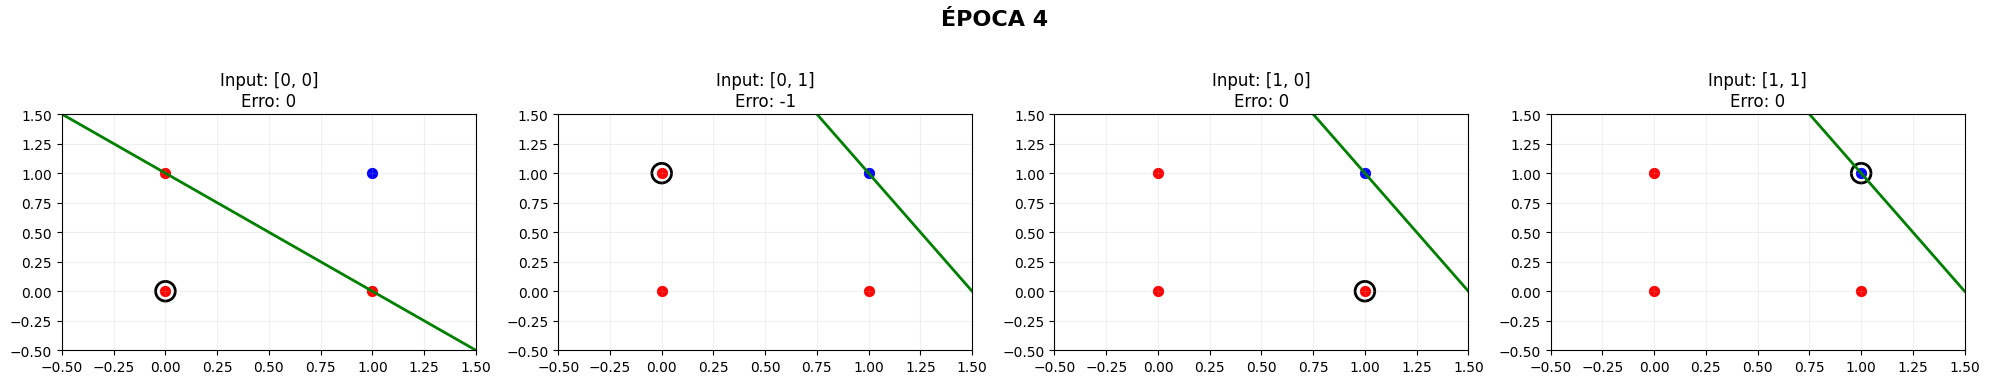

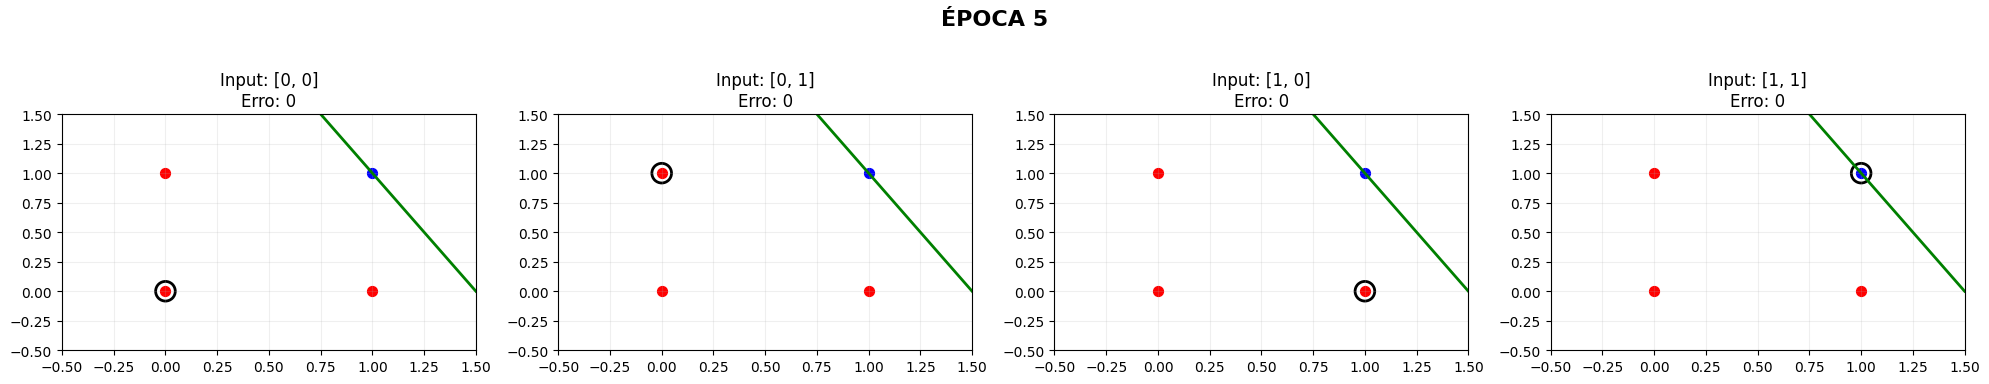

*** CONVERGÊNCIA NA ÉPOCA 5! ***

--- Treino Finalizado! O neurônio convergiu. ---
Pesos Finais: [0.04, 0.02]
Bias Final: -0.06



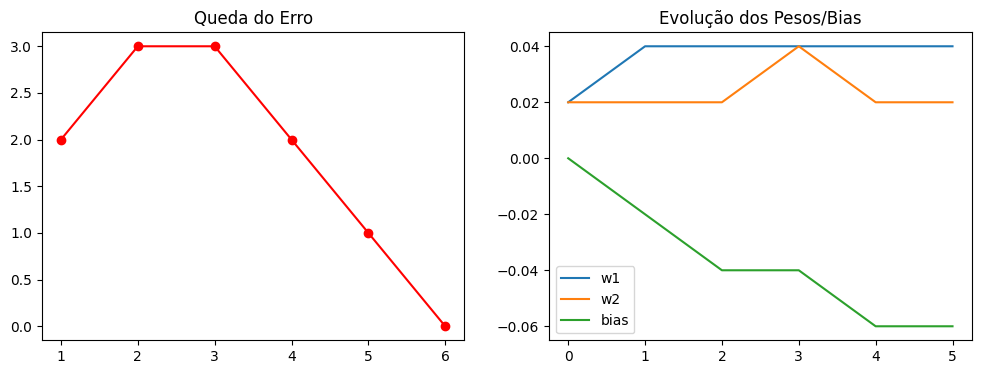

In [ ]:
def degrau(x):
  if x >= 0:
    return 1
  else:
    return 0

def perceptron(input,target,weight,bias):

  fator_aprendizado = 0.02
  somatorio = bias

  for i in range(len(input)):
    a = (input[i]*weight[i])
    somatorio += a

  valor_calculado = degrau(somatorio)
  erro = target - valor_calculado

  new_weight = []

  for i in range(len(weight)):
    weight_new = weight[i] + (fator_aprendizado*erro*input[i])
    new_weight.append(weight_new)

  bias_new = bias + (fator_aprendizado*erro)

  return new_weight, bias_new, erro


inputs = [[0,0],[0,1],[1,0],[1,1]]
targets = [0,0,0,1]
w = [0,0]
b = 0

hist_erros = [] # Lista para o historico de erros
hist_pesos = [] # Lista para o historico de pesos
hist_bias = []  # Lista para o hisotorico de bias

# --- Treinamento com Gráficos Lado a Lado por Entrada ---

import matplotlib.pyplot as plt
import numpy as np

# um for com 20 epocas, que seriam 20 ciclos de treinamento.
for epoca in range(20):

    #variavel para contar os erros na epoca
    erros_na_epoca = 0

    # Cria uma grade com 1 linha e 4 colunas.
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # Cria e centraliza um título para a figura criada.
    fig.suptitle(f"ÉPOCA {epoca}", fontsize=16, fontweight='bold')

    # Um for que percorre cada par de entrada.
    for i in range(len(inputs)):

        # Executa o neurônio
        w, b, e = perceptron(inputs[i], targets[i], w, b)

        # Caso erro seja diferente de zero, adiciona 1 na variavel erros na epoca
        if e != 0:
            erros_na_epoca += 1

        # Seleciona em qual dos 4 mini-gráficos (da esquerda para a direita) vamos desenhar agora.
        ax = axes[i]

        # Desenha os pontos Vermelhos na tela.
        ax.scatter([0,0,1], [0,1,0], color='red', s=50)

        # Desenha o ponto Azul na tela.
        ax.scatter([1], [1], color='blue', s=50)

        # Desenha um círculo preto grande e vazio ao redor do ponto que o neurônio está testando neste exato momento.
        ax.scatter(inputs[i][0], inputs[i][1], facecolors='none', edgecolors='black', s=200, linewidth=2, label='Teste Atual')

        # Cria uma lista de 10 números entre -0.5 e 1.5 para servirem de base (eixo X) para desenhar a linha.
        x_range = np.linspace(-0.5, 1.5, 10)

        # Evita a divisão por zero se w2 for 0.
        if w[1] != 0:
            # Calcula a altura da reta (eixo Y), baseada na formula da Fronteira de Decisões.
            y_range = (-w[0] * x_range - b) / w[1]

            # Desenha a linha verde (fronteira) cruzando o gráfico.
            ax.plot(x_range, y_range, color='green', linewidth=2)

        # Coloca o título em cima do mini-gráfico mostrando qual foi a entrada e se houve erro.
        ax.set_title(f"Input: {inputs[i]}\nErro: {e}")

        # Define os limites visuais do gráfico para que ele não mude de tamanho e fique sempre entre -0.5 e 1.5.
        ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)

        # Adiciona aquelas linhas de grade um pouco claras ao fundo.
        ax.grid(True, alpha=0.2)

    # Ajusta automaticamente o espaçamento para que os títulos e nomes dos eixos não fiquem amontoados.
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # Manda o computador imprimir todos os 4 gráficos daquela época na tela do Colab.
    plt.show()

    hist_erros.append(erros_na_epoca) # Salva os erros da epoca na lista de historico de Erros
    hist_pesos.append(list(w)) # Salva os valores dos pesos utilizados na lista de historico de Pesos.
    hist_bias.append(b) # Salva os valores de Bias utilizados na lista de  historico de Bias.

    # Caso não haja erros na epoca, o programa converge e para ali mesmo.
    if erros_na_epoca == 0:
        print(f"*** CONVERGÊNCIA NA ÉPOCA {epoca}! ***")
        break

print("")
print("--- Treino Finalizado! O neurônio convergiu. ---")
print(f"Pesos Finais: {w}")
print(f"Bias Final: {b}")
print("")

# Cria uma moldura com 1 linha e 2 colunas para colocar os gráficos de resumo lado a lado.
fig_final, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# No primeiro gráfico (ax1), desenha a linha vermelha mostrando a contagem de erros por época.
ax1.plot(range(1, len(hist_erros)+1), hist_erros, marker='o', color='red')

# Define o título do primeiro gráfico como "Queda do Erro".
ax1.set_title("Queda do Erro")

# Converte a lista de pesos em um formato de matriz (NumPy Array) para facilitar o acesso às colunas.
w_arr = np.array(hist_pesos)

# No segundo gráfico (ax2), desenha as linhas de evolução para o Peso 1 (w1), Peso 2 (w2) e o Bias.
ax2.plot(w_arr[:, 0], label='w1'); ax2.plot(w_arr[:, 1], label='w2'); ax2.plot(hist_bias, label='bias')

# Define o título do segundo gráfico e adiciona a legenda para identificar qual linha é qual parâmetro.
ax2.set_title("Evolução dos Pesos/Bias"); ax2.legend()

#Finaliza e exibe as figuras de resumo na tela do seu Colab.
plt.show()

#Conclusão:

###- A conclusão que podemos tirar sobre o modelo, é que ele funciona bem para encontrar a fronteira de decisão para a porta lógica AND, mesmo com o fator de aprendizagem em 0.02 = 2%, o algoritmo foi rápido em minimizar o erro e convergir. Nos gráficos gerados, podemos observar o valor dos pesos e bias alterando até estabilizarem, e consequentemente levando o erro a zero, comprovando a eficácia do modelo para uma classificação binária simples. Não podemos esquecer dos gráficos de cada época, que mostram a fronteira de decisão se atualizando a cada época, até o erro zerar, definindo-a de fato.